# 10 — Object-Centric Crop + Alignment + Query-Gated UVD

## Goal

Notebook 07 showed that **object-centric cropping + part-query alignment** is the strongest model configuration so far, especially on unseen parent-object categories.

Notebook 09 showed that **query-gated UVD geometry** learns query-dependent spatial preferences, but only gives a very small aggregate improvement in the simpler full-image architecture. The learned gate also saturated toward near-binary U/V selection while largely ignoring the D channel.

This notebook tests whether query-gated geometry becomes more useful when integrated into the strongest existing object-centric model.

## Models Compared

1. **Crop + Alignment**
2. **Crop + Alignment + Fixed UVD**
3. **Crop + Alignment + Query-Gated UVD**

All three models use the same dataset splits, object-centric crop procedure, frozen DINOv2 encoder, frozen CLIP text encoder, alignment mechanism, decoder family, loss, threshold, and full-image evaluation procedure.

## Research Question

> Does query-adaptive object-relative UVD geometry improve the strongest object-centric part-query alignment model, particularly on unseen parent-object categories?

## Imports and Configuration

The experiment reuses the crop/alignment pipeline from Notebook 07 and the UVD/gating components from Notebook 09.

In [3]:
from pathlib import Path
import sys
import json
import random
import time
import math
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from torchvision.transforms import functional as TF
from torchvision.transforms import InterpolationMode

from scipy.ndimage import distance_transform_edt

import open_clip

In [4]:
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

PROJECT_ROOT = PROJECT_ROOT.resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

Project root: /home/hpc/v123be/v123be51/cv_notebooks/Computer_Vision_Object-Relative-Spatial-Encoding-for-Open-Vocabulary-Part-Segmentation


In [5]:
SEED = 42
IMAGE_SIZE = 224

TRAIN_BATCH_SIZE = 16
VAL_BATCH_SIZE = 16
NUM_WORKERS = 8
PIN_MEMORY = torch.cuda.is_available()

EPOCHS = 20
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
MASK_THRESHOLD = 0.5

VISUAL_DIM = 128
TEXT_COMMON_DIM = 128
TEXT_DECODER_DIM = 32
GATE_HIDDEN_DIM = 64

ALIGNMENT_TEMPERATURE = 0.10
ALIGNMENT_LOSS_WEIGHT = 0.20
CROP_CONTEXT_RATIO = 0.15

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = DEVICE.type == "cuda"

OUTPUT_ROOT = (
    PROJECT_ROOT
    / "outputs"
    / "experiments"
    / "crop_alignment_query_gated_uvd"
)
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

print("Device:", DEVICE)
print("AMP:", USE_AMP)
print("Workers:", NUM_WORKERS)
print("Output:", OUTPUT_ROOT)

Device: cuda
AMP: True
Workers: 8
Output: /home/hpc/v123be/v123be51/cv_notebooks/Computer_Vision_Object-Relative-Spatial-Encoding-for-Open-Vocabulary-Part-Segmentation/outputs/experiments/crop_alignment_query_gated_uvd


In [6]:
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything(SEED)
print("Seed:", SEED)

Seed: 42


## Dataset

We use the same Pascal-Part-116 split protocol as the previous experiments:

- `train_seen`: 32,698 part-query samples
- `validation_seen`: 3,708
- `test_seen`: 3,371
- `test_unseen`: 1,586

Training and validation use seen parent-object categories. Final evaluation separately measures seen and unseen parent-object generalization.

In [7]:
from datasets import PascalPart116Dataset

PROCESSED_DATA_ROOT = PROJECT_ROOT / "data" / "processed"

for split in [
    "train_seen",
    "validation_seen",
    "test_seen",
    "test_unseen",
]:
    ds = PascalPart116Dataset(
        split=split,
        processed_dir=PROCESSED_DATA_ROOT,
    )
    print(f"{split:20s}: {len(ds)}")

train_seen          : 32698
validation_seen     : 3708
test_seen           : 3371
test_unseen         : 1586


## Object-Centric Preprocessing

This section follows Notebook 07. The parent-object mask defines a square crop with 15% context. The crop is resized directly from the original image to 224×224, increasing the number of DINO patches allocated to the selected object.

For fair final evaluation, the notebook also keeps a full-image representation and the crop mapping metadata required to project crop predictions back into full-image coordinates.

In [8]:
IMAGENET_MEAN = torch.tensor(
    [0.485, 0.456, 0.406],
    dtype=torch.float32,
).view(3, 1, 1)

IMAGENET_STD = torch.tensor(
    [0.229, 0.224, 0.225],
    dtype=torch.float32,
).view(3, 1, 1)

In [9]:
def get_resize_info(height, width, target_size=224):
    scale = min(
        target_size / height,
        target_size / width,
    )

    new_h = max(1, round(height * scale))
    new_w = max(1, round(width * scale))

    pad_h = target_size - new_h
    pad_w = target_size - new_w

    top = pad_h // 2
    bottom = pad_h - top
    left = pad_w // 2
    right = pad_w - left

    return {
        "new_h": new_h,
        "new_w": new_w,
        "top": top,
        "bottom": bottom,
        "left": left,
        "right": right,
        "scale": scale,
    }

In [10]:
def preprocess_full_image(image, target_size=224):
    image = image.float() / 255.0
    _, h, w = image.shape

    info = get_resize_info(h, w, target_size)

    resized = TF.resize(
        image,
        [info["new_h"], info["new_w"]],
        interpolation=InterpolationMode.BILINEAR,
        antialias=True,
    )

    display_image = F.pad(
        resized,
        (info["left"], info["right"], info["top"], info["bottom"]),
        value=0.0,
    )

    normalized = (resized - IMAGENET_MEAN) / IMAGENET_STD

    model_image = F.pad(
        normalized,
        (info["left"], info["right"], info["top"], info["bottom"]),
        value=0.0,
    )

    return display_image, model_image, info

In [11]:
def preprocess_full_mask(mask, resize_info, preserve_positive=False):
    if mask.ndim == 2:
        mask = mask.unsqueeze(0)

    mask = mask.float()

    resized = TF.resize(
        mask,
        [resize_info["new_h"], resize_info["new_w"]],
        interpolation=InterpolationMode.NEAREST,
    )

    if preserve_positive and mask.sum() > 0 and resized.sum() == 0:
        resized = F.interpolate(
            mask.unsqueeze(0),
            size=(resize_info["new_h"], resize_info["new_w"]),
            mode="area",
        ).squeeze(0)
        resized = (resized > 0).float()

    padded = F.pad(
        resized,
        (
            resize_info["left"],
            resize_info["right"],
            resize_info["top"],
            resize_info["bottom"],
        ),
        value=0.0,
    )

    return padded > 0.5

In [12]:
def create_relative_uv(object_mask):
    if object_mask.ndim == 3:
        mask = object_mask.squeeze(0)
    else:
        mask = object_mask

    mask = mask.bool()
    h, w = mask.shape

    u = torch.zeros((h, w), dtype=torch.float32)
    v = torch.zeros((h, w), dtype=torch.float32)

    ys, xs = torch.where(mask)

    if len(xs) == 0:
        return u.unsqueeze(0), v.unsqueeze(0)

    x_min = xs.min()
    x_max = xs.max()
    y_min = ys.min()
    y_max = ys.max()

    x_denom = max(int(x_max - x_min), 1)
    y_denom = max(int(y_max - y_min), 1)

    u_values = (xs.float() - x_min.float()) / x_denom
    v_values = (ys.float() - y_min.float()) / y_denom

    u[ys, xs] = u_values
    v[ys, xs] = v_values

    return u.unsqueeze(0), v.unsqueeze(0)

In [13]:
def create_boundary_distance(object_mask):
    if object_mask.ndim == 3:
        mask = object_mask.squeeze(0)
    else:
        mask = object_mask

    mask = mask.bool()
    h, w = mask.shape

    d_map = torch.zeros((h, w), dtype=torch.float32)

    if not mask.any():
        return d_map.unsqueeze(0)

    mask_np = mask.cpu().numpy().astype(np.uint8)
    distance = distance_transform_edt(mask_np)

    max_distance = distance.max()
    if max_distance > 0:
        distance = distance / max_distance

    d_map = torch.from_numpy(distance).float()
    d_map = d_map * mask.float()

    return d_map.unsqueeze(0)

In [14]:
def get_square_object_crop(object_mask, context_ratio=0.15):
    if object_mask.ndim == 3:
        mask = object_mask.squeeze(0)
    else:
        mask = object_mask

    mask = mask.bool()
    h, w = mask.shape
    ys, xs = torch.where(mask)

    if len(xs) == 0:
        side = max(h, w)
        return {
            "x1": (w - side) // 2,
            "y1": (h - side) // 2,
            "side": side,
        }

    x_min = xs.min().item()
    x_max = xs.max().item() + 1
    y_min = ys.min().item()
    y_max = ys.max().item() + 1

    box_width = x_max - x_min
    box_height = y_max - y_min
    base_side = max(box_width, box_height)

    side = math.ceil(base_side * (1 + 2 * context_ratio))
    side = max(side, 1)

    center_x = (x_min + x_max) / 2
    center_y = (y_min + y_max) / 2

    x1 = math.floor(center_x - side / 2)
    y1 = math.floor(center_y - side / 2)

    return {"x1": x1, "y1": y1, "side": side}

In [15]:
def square_crop_with_padding(tensor, x1, y1, side, fill_value=0):
    original_ndim = tensor.ndim

    if tensor.ndim == 2:
        tensor = tensor.unsqueeze(0)

    channels, h, w = tensor.shape

    output = torch.full(
        (channels, side, side),
        fill_value=fill_value,
        dtype=tensor.dtype,
    )

    x2 = x1 + side
    y2 = y1 + side

    source_x1 = max(0, x1)
    source_y1 = max(0, y1)
    source_x2 = min(w, x2)
    source_y2 = min(h, y2)

    destination_x1 = source_x1 - x1
    destination_y1 = source_y1 - y1
    destination_x2 = destination_x1 + source_x2 - source_x1
    destination_y2 = destination_y1 + source_y2 - source_y1

    if source_x1 < source_x2 and source_y1 < source_y2:
        output[
            :,
            destination_y1:destination_y2,
            destination_x1:destination_x2,
        ] = tensor[
            :,
            source_y1:source_y2,
            source_x1:source_x2,
        ]

    if original_ndim == 2:
        output = output.squeeze(0)

    return output

In [16]:
def prepare_crop_image(crop_image, target_size=224):
    crop_image = crop_image.float() / 255.0

    display_image = TF.resize(
        crop_image,
        [target_size, target_size],
        interpolation=InterpolationMode.BILINEAR,
        antialias=True,
    )

    model_image = (display_image - IMAGENET_MEAN) / IMAGENET_STD

    return display_image, model_image

In [17]:
def prepare_crop_mask(crop_mask, target_size=224, preserve_positive=False):
    if crop_mask.ndim == 2:
        crop_mask = crop_mask.unsqueeze(0)

    crop_mask = crop_mask.float()

    resized = TF.resize(
        crop_mask,
        [target_size, target_size],
        interpolation=InterpolationMode.NEAREST,
    )

    if preserve_positive and crop_mask.sum() > 0 and resized.sum() == 0:
        resized = F.interpolate(
            crop_mask.unsqueeze(0),
            size=(target_size, target_size),
            mode="area",
        ).squeeze(0)
        resized = (resized > 0).float()

    return resized > 0.5

## Object-Centric UVD Dataset

The wrapper preserves Notebook 07's full-view and crop-view representations and adds the crop-space boundary-distance channel `D` from Notebook 09.

`U`, `V`, and `D` are computed from the resized parent-object crop, so every model receives geometry in the same crop coordinate system used by DINOv2.

In [18]:
class ObjectCentricUVDDataset(Dataset):
    def __init__(
        self,
        split,
        processed_dir=PROCESSED_DATA_ROOT,
        image_size=224,
        context_ratio=0.15,
    ):
        self.base_dataset = PascalPart116Dataset(
            split=split,
            processed_dir=processed_dir,
        )
        self.image_size = image_size
        self.context_ratio = context_ratio

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, index):
        sample = self.base_dataset[index]

        original_image = sample["image"]
        original_object = sample["object_mask"]
        original_part = sample["part_mask"]
        _, original_h, original_w = original_image.shape

        full_display, full_image, full_resize_info = preprocess_full_image(
            original_image,
            self.image_size,
        )

        full_object = preprocess_full_mask(
            original_object,
            full_resize_info,
            preserve_positive=True,
        )

        full_part = preprocess_full_mask(
            original_part,
            full_resize_info,
            preserve_positive=True,
        )

        if full_part.any() and not (full_part & full_object).any():
            full_object = full_object | full_part

        full_part = full_part & full_object

        crop_info = get_square_object_crop(
            original_object,
            self.context_ratio,
        )

        x1 = crop_info["x1"]
        y1 = crop_info["y1"]
        side = crop_info["side"]

        crop_rgb_raw = square_crop_with_padding(
            original_image,
            x1,
            y1,
            side,
            fill_value=0,
        )

        crop_object_raw = square_crop_with_padding(
            original_object,
            x1,
            y1,
            side,
            fill_value=0,
        )

        crop_part_raw = square_crop_with_padding(
            original_part,
            x1,
            y1,
            side,
            fill_value=0,
        )

        crop_display, crop_image = prepare_crop_image(
            crop_rgb_raw,
            self.image_size,
        )

        crop_object = prepare_crop_mask(
            crop_object_raw,
            self.image_size,
            preserve_positive=True,
        )

        crop_part = prepare_crop_mask(
            crop_part_raw,
            self.image_size,
            preserve_positive=True,
        )

        if crop_part.any() and not (crop_part & crop_object).any():
            crop_object = crop_object | crop_part

        crop_part = crop_part & crop_object

        crop_u, crop_v = create_relative_uv(crop_object)
        crop_d = create_boundary_distance(crop_object)

        part_to_object_ratio = (
            full_part.sum().float()
            / full_object.sum().float().clamp_min(1)
        )

        return {
            "sample_id": sample["sample_id"],
            "image_id": sample["image_id"],
            "query": sample["query"],
            "object_name": sample["object_name"],
            "part_name": sample["part_name"],
            "full_display_image": full_display,
            "full_image": full_image,
            "full_object_mask": full_object.float(),
            "full_part_mask": full_part.float(),
            "crop_display_image": crop_display,
            "crop_image": crop_image,
            "crop_object_mask": crop_object.float(),
            "crop_part_mask": crop_part.float(),
            "crop_relative_u": crop_u,
            "crop_relative_v": crop_v,
            "crop_boundary_d": crop_d,
            "original_height": original_h,
            "original_width": original_w,
            "crop_x1": x1,
            "crop_y1": y1,
            "crop_side": side,
            "part_to_object_ratio": part_to_object_ratio,
        }

In [19]:
train_dataset = ObjectCentricUVDDataset(
    split="train_seen",
    image_size=IMAGE_SIZE,
    context_ratio=CROP_CONTEXT_RATIO,
)

val_dataset = ObjectCentricUVDDataset(
    split="validation_seen",
    image_size=IMAGE_SIZE,
    context_ratio=CROP_CONTEXT_RATIO,
)

test_seen_dataset = ObjectCentricUVDDataset(
    split="test_seen",
    image_size=IMAGE_SIZE,
    context_ratio=CROP_CONTEXT_RATIO,
)

test_unseen_dataset = ObjectCentricUVDDataset(
    split="test_unseen",
    image_size=IMAGE_SIZE,
    context_ratio=CROP_CONTEXT_RATIO,
)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test seen:", len(test_seen_dataset))
print("Test unseen:", len(test_unseen_dataset))

Train: 32698
Validation: 3708
Test seen: 3371
Test unseen: 1586


In [20]:
sample = train_dataset[0]

for key in [
    "crop_image",
    "crop_object_mask",
    "crop_part_mask",
    "crop_relative_u",
    "crop_relative_v",
    "crop_boundary_d",
    "full_part_mask",
]:
    print(f"{key:20s}", sample[key].shape)

print("Query:", sample["query"])
print("Object:", sample["object_name"])
print("Part:", sample["part_name"])

crop_image           torch.Size([3, 224, 224])
crop_object_mask     torch.Size([1, 224, 224])
crop_part_mask       torch.Size([1, 224, 224])
crop_relative_u      torch.Size([1, 224, 224])
crop_relative_v      torch.Size([1, 224, 224])
crop_boundary_d      torch.Size([1, 224, 224])
full_part_mask       torch.Size([1, 224, 224])
Query: screen
Object: tvmonitor
Part: screen


## DataLoaders

Eight workers are used on the cluster because U/V/D preprocessing—especially the SciPy distance transform for `D`—is CPU-side. This avoids leaving the A100 idle while waiting for samples.

In [21]:
train_loader = DataLoader(
    train_dataset,
    batch_size=TRAIN_BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=NUM_WORKERS > 0,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=VAL_BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=NUM_WORKERS > 0,
)

test_seen_loader = DataLoader(
    test_seen_dataset,
    batch_size=VAL_BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=NUM_WORKERS > 0,
)

test_unseen_loader = DataLoader(
    test_unseen_dataset,
    batch_size=VAL_BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=NUM_WORKERS > 0,
)

print("DataLoaders ready.")

DataLoaders ready.


In [22]:
batch = next(iter(train_loader))

for key in [
    "crop_image",
    "crop_object_mask",
    "crop_part_mask",
    "crop_relative_u",
    "crop_relative_v",
    "crop_boundary_d",
]:
    print(f"{key:20s}", batch[key].shape)

crop_image           torch.Size([16, 3, 224, 224])
crop_object_mask     torch.Size([16, 1, 224, 224])
crop_part_mask       torch.Size([16, 1, 224, 224])
crop_relative_u      torch.Size([16, 1, 224, 224])
crop_relative_v      torch.Size([16, 1, 224, 224])
crop_boundary_d      torch.Size([16, 1, 224, 224])


## Frozen DINOv2 and CLIP Encoders

DINOv2 ViT-S/14 provides spatial patch features. CLIP ViT-B/32 provides the part-query embedding. Both encoders remain frozen so the comparison isolates the lightweight segmentation, alignment, and geometry-fusion components.

In [24]:
dino = torch.hub.load(
    "facebookresearch/dinov2",
    "dinov2_vits14",
)

dino = dino.to(DEVICE)
dino.eval()

for p in dino.parameters():
    p.requires_grad = False

print("DINOv2 loaded and frozen.")

Using cache found in /home/hpc/v123be/v123be51/.cache/torch/hub/facebookresearch_dinov2_main
/home/hpc/v123be/v123be51/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/home/hpc/v123be/v123be51/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/home/hpc/v123be/v123be51/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


DINOv2 loaded and frozen.


In [25]:
clip_model, _, _ = open_clip.create_model_and_transforms(
    "ViT-B-32",
    pretrained="openai",
)

clip_tokenizer = open_clip.get_tokenizer("ViT-B-32")

clip_model = clip_model.to(DEVICE)
clip_model.eval()

for p in clip_model.parameters():
    p.requires_grad = False

print("CLIP loaded and frozen.")

/home/hpc/v123be/v123be51/cv_notebooks/Computer_Vision_Object-Relative-Spatial-Encoding-for-Open-Vocabulary-Part-Segmentation/.venv/lib/python3.12/site-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


CLIP loaded and frozen.


In [26]:
class TextEmbeddingCache:
    def __init__(self, model, tokenizer, device):
        self.model = model
        self.tokenizer = tokenizer
        self.device = device
        self.cache = {}

    @torch.no_grad()
    def _encode_missing(self, queries):
        missing = sorted({q for q in queries if q not in self.cache})

        if not missing:
            return

        prompts = [
            f"a photo of the {q} of an object"
            for q in missing
        ]

        tokens = self.tokenizer(prompts).to(self.device)
        embeddings = self.model.encode_text(tokens)
        embeddings = F.normalize(embeddings.float(), dim=-1)

        for query, embedding in zip(missing, embeddings):
            self.cache[query] = embedding.detach().cpu()

    def __call__(self, queries):
        self._encode_missing(queries)
        result = torch.stack([self.cache[q] for q in queries])
        return result.to(self.device, non_blocking=True)

text_encoder = TextEmbeddingCache(
    clip_model,
    clip_tokenizer,
    DEVICE,
)

print("Text embedding cache ready.")

Text embedding cache ready.


## Combined Crop + Alignment + UVD Model

All three variants share one architecture and differ only in how the geometry channels are supplied:

- `crop_alignment`: alignment is active; U/V/D inputs are zeroed.
- `crop_alignment_fixed_uvd`: alignment is active; raw U/V/D are supplied.
- `crop_alignment_query_gated_uvd`: alignment is active; the CLIP query predicts softmax weights `(αU, αV, αD)` that scale the three geometry channels.

Using one decoder shape for all modes keeps the comparison controlled.

In [27]:
class QueryGeometryGate(nn.Module):
    def __init__(self, input_dim=512, hidden_dim=64):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, 3),
        )

    def forward(self, text_embeddings):
        gate_logits = self.network(text_embeddings)
        return F.softmax(gate_logits, dim=-1)

In [28]:
class CropAlignmentUVDSegmenter(nn.Module):
    def __init__(
        self,
        dino_encoder,
        mode,
        visual_dim=128,
        text_common_dim=128,
        text_decoder_dim=32,
        temperature=0.10,
        gate_hidden_dim=64,
    ):
        super().__init__()

        assert mode in {
            "crop_alignment",
            "crop_alignment_fixed_uvd",
            "crop_alignment_query_gated_uvd",
        }

        self.mode = mode
        self.temperature = temperature
        self.dino = dino_encoder

        for p in self.dino.parameters():
            p.requires_grad = False

        self.visual_projection = nn.Conv2d(
            384,
            visual_dim,
            kernel_size=1,
        )

        self.text_projection = nn.Sequential(
            nn.Linear(512, text_common_dim),
            nn.GELU(),
        )

        self.text_decoder_projection = nn.Linear(
            text_common_dim,
            text_decoder_dim,
        )

        if mode == "crop_alignment_query_gated_uvd":
            self.geometry_gate = QueryGeometryGate(
                input_dim=512,
                hidden_dim=gate_hidden_dim,
            )
        else:
            self.geometry_gate = None

        fusion_dim = (
            visual_dim
            + text_decoder_dim
            + 1  # parent-object mask
            + 3  # U, V, D
            + 1  # part-query alignment map
        )

        self.decoder = nn.Sequential(
            nn.Conv2d(fusion_dim, 128, kernel_size=3, padding=1),
            nn.GroupNorm(8, 128),
            nn.GELU(),
            nn.Conv2d(128, 64, kernel_size=3, padding=1),
            nn.GroupNorm(8, 64),
            nn.GELU(),
            nn.Conv2d(64, 32, kernel_size=3, padding=1),
            nn.GELU(),
            nn.Conv2d(32, 1, kernel_size=1),
        )

    def train(self, mode=True):
        super().train(mode)
        self.dino.eval()
        return self

    @torch.no_grad()
    def extract_dino_features(self, images):
        output = self.dino.forward_features(images)
        tokens = output["x_norm_patchtokens"]
        b, n, c = tokens.shape
        grid = int(n ** 0.5)

        return (
            tokens
            .transpose(1, 2)
            .reshape(b, c, grid, grid)
        )

    def compute_alignment(self, visual, text_common):
        visual_normalized = F.normalize(visual, dim=1)
        text_normalized = F.normalize(text_common, dim=1)
        text_spatial = text_normalized[:, :, None, None]

        cosine_similarity = (
            visual_normalized * text_spatial
        ).sum(dim=1, keepdim=True)

        alignment_logits = cosine_similarity / self.temperature
        alignment_probability = torch.sigmoid(alignment_logits)

        return alignment_logits, alignment_probability

    def forward(
        self,
        images,
        text_embeddings,
        object_mask,
        relative_u,
        relative_v,
        boundary_d,
        return_gate_weights=False,
    ):
        dino_features = self.extract_dino_features(images)
        visual = self.visual_projection(dino_features)

        text_common = self.text_projection(text_embeddings)
        text_decoder = self.text_decoder_projection(text_common)

        text_map = text_decoder[:, :, None, None].expand(
            -1,
            -1,
            visual.shape[-2],
            visual.shape[-1],
        )

        alignment_logits, alignment_probability = self.compute_alignment(
            visual,
            text_common,
        )

        spatial_size = visual.shape[-2:]

        mask_low = F.interpolate(
            object_mask,
            size=spatial_size,
            mode="nearest",
        )

        alignment_map = alignment_probability * mask_low

        u_low = F.interpolate(
            relative_u,
            size=spatial_size,
            mode="bilinear",
            align_corners=False,
        ) * mask_low

        v_low = F.interpolate(
            relative_v,
            size=spatial_size,
            mode="bilinear",
            align_corners=False,
        ) * mask_low

        d_low = F.interpolate(
            boundary_d,
            size=spatial_size,
            mode="bilinear",
            align_corners=False,
        ) * mask_low

        if self.mode == "crop_alignment":
            gate_weights = torch.zeros(
                (images.shape[0], 3),
                device=images.device,
                dtype=visual.dtype,
            )
            weighted_u = torch.zeros_like(u_low)
            weighted_v = torch.zeros_like(v_low)
            weighted_d = torch.zeros_like(d_low)

        elif self.mode == "crop_alignment_fixed_uvd":
            gate_weights = torch.ones(
                (images.shape[0], 3),
                device=images.device,
                dtype=visual.dtype,
            )
            weighted_u = u_low
            weighted_v = v_low
            weighted_d = d_low

        else:
            gate_weights = self.geometry_gate(text_embeddings.float())

            alpha_u = gate_weights[:, 0].view(-1, 1, 1, 1)
            alpha_v = gate_weights[:, 1].view(-1, 1, 1, 1)
            alpha_d = gate_weights[:, 2].view(-1, 1, 1, 1)

            weighted_u = alpha_u * u_low
            weighted_v = alpha_v * v_low
            weighted_d = alpha_d * d_low

        fused = torch.cat(
            [
                visual,
                text_map,
                mask_low,
                weighted_u,
                weighted_v,
                weighted_d,
                alignment_map,
            ],
            dim=1,
        )

        logits_low = self.decoder(fused)

        logits = F.interpolate(
            logits_low,
            size=images.shape[-2:],
            mode="bilinear",
            align_corners=False,
        )

        aux = {
            "alignment_logits": alignment_logits,
            "alignment_map": alignment_map,
            "gate_weights": gate_weights,
        }

        if return_gate_weights:
            return logits, aux, gate_weights

        return logits, aux

In [29]:
for mode in [
    "crop_alignment",
    "crop_alignment_fixed_uvd",
    "crop_alignment_query_gated_uvd",
]:
    model = CropAlignmentUVDSegmenter(
        dino_encoder=dino,
        mode=mode,
        visual_dim=VISUAL_DIM,
        text_common_dim=TEXT_COMMON_DIM,
        text_decoder_dim=TEXT_DECODER_DIM,
        temperature=ALIGNMENT_TEMPERATURE,
        gate_hidden_dim=GATE_HIDDEN_DIM,
    )

    trainable = sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )

    print(f"{mode:38s} {trainable:,} trainable parameters")

crop_alignment                         401,953 trainable parameters
crop_alignment_fixed_uvd               401,953 trainable parameters
crop_alignment_query_gated_uvd         434,980 trainable parameters


## Losses and Metrics

Every model uses the same segmentation loss (BCE + Dice) and the same auxiliary part-query alignment loss from Notebook 07. The only experimental variable is the geometry input.

In [30]:
def create_alignment_targets(part_mask, object_mask, output_size):
    target_low = F.adaptive_max_pool2d(part_mask, output_size)
    valid_low = F.adaptive_max_pool2d(object_mask, output_size)
    target_low *= valid_low
    return target_low, valid_low


def dice_loss(logits, targets, eps=1e-6):
    probabilities = torch.sigmoid(logits).flatten(1)
    targets = targets.flatten(1)

    intersection = (probabilities * targets).sum(dim=1)
    denominator = probabilities.sum(dim=1) + targets.sum(dim=1)

    dice = (2 * intersection + eps) / (denominator + eps)
    return (1 - dice).mean()


def segmentation_loss(logits, targets):
    bce = F.binary_cross_entropy_with_logits(logits, targets)
    dice = dice_loss(logits, targets)
    return bce + dice

In [31]:
def alignment_loss(alignment_logits, part_mask, object_mask):
    target_low, valid_low = create_alignment_targets(
        part_mask,
        object_mask,
        alignment_logits.shape[-2:],
    )

    loss_map = F.binary_cross_entropy_with_logits(
        alignment_logits,
        target_low,
        reduction="none",
    )

    bce = (
        (loss_map * valid_low).sum()
        / valid_low.sum().clamp_min(1.0)
    )

    probability = torch.sigmoid(alignment_logits) * valid_low
    target = target_low * valid_low

    probability = probability.flatten(1)
    target = target.flatten(1)

    intersection = (probability * target).sum(dim=1)
    denominator = probability.sum(dim=1) + target.sum(dim=1)

    dice = (
        1
        - (2 * intersection + 1e-6)
        / (denominator + 1e-6)
    ).mean()

    return bce + dice


def compute_total_loss(logits, aux, part_mask, object_mask):
    seg = segmentation_loss(logits, part_mask)

    align = alignment_loss(
        aux["alignment_logits"],
        part_mask,
        object_mask,
    )

    return seg + ALIGNMENT_LOSS_WEIGHT * align

In [32]:
@torch.no_grad()
def batch_iou(logits, targets, threshold=0.5, eps=1e-6):
    predictions = torch.sigmoid(logits) >= threshold
    targets = targets >= 0.5

    predictions = predictions.flatten(1)
    targets = targets.flatten(1)

    intersection = (predictions & targets).sum(dim=1).float()
    union = (predictions | targets).sum(dim=1).float()

    return (intersection + eps) / (union + eps)


@torch.no_grad()
def batch_dice(logits, targets, threshold=0.5, eps=1e-6):
    predictions = torch.sigmoid(logits) >= threshold
    targets = targets >= 0.5

    predictions = predictions.flatten(1)
    targets = targets.flatten(1)

    intersection = (predictions & targets).sum(dim=1).float()
    denominator = predictions.sum(dim=1).float() + targets.sum(dim=1).float()

    return (2 * intersection + eps) / (denominator + eps)

## Training Loop and Checkpointing

Validation IoU selects `best.pt`. Checkpoints store only trainable submodules because DINOv2 and CLIP are frozen and reconstructed when loading.

In [33]:
def run_crop_epoch(
    model,
    loader,
    optimizer=None,
    scaler=None,
    threshold=MASK_THRESHOLD,
    max_batches=None,
):
    training = optimizer is not None

    if training:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    total_iou = 0.0
    total_dice = 0.0
    total_samples = 0

    for batch_index, batch in enumerate(loader):
        if max_batches is not None and batch_index >= max_batches:
            break

        images = batch["crop_image"].to(DEVICE, non_blocking=True)
        objects = batch["crop_object_mask"].to(DEVICE, non_blocking=True)
        targets = batch["crop_part_mask"].to(DEVICE, non_blocking=True)
        u = batch["crop_relative_u"].to(DEVICE, non_blocking=True)
        v = batch["crop_relative_v"].to(DEVICE, non_blocking=True)
        d = batch["crop_boundary_d"].to(DEVICE, non_blocking=True)

        text = text_encoder(batch["query"])
        batch_size = images.shape[0]

        if training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(training):
            with torch.autocast(
                device_type=DEVICE.type,
                dtype=torch.float16,
                enabled=USE_AMP,
            ):
                logits, aux = model(
                    images,
                    text,
                    objects,
                    u,
                    v,
                    d,
                )

                loss = compute_total_loss(
                    logits,
                    aux,
                    targets,
                    objects,
                )

            if training:
                if scaler is not None and USE_AMP:
                    scaler.scale(loss).backward()
                    scaler.unscale_(optimizer)

                    torch.nn.utils.clip_grad_norm_(
                        (p for p in model.parameters() if p.requires_grad),
                        1.0,
                    )

                    scaler.step(optimizer)
                    scaler.update()
                else:
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(
                        (p for p in model.parameters() if p.requires_grad),
                        1.0,
                    )
                    optimizer.step()

        with torch.no_grad():
            ious = batch_iou(logits, targets, threshold)
            dices = batch_dice(logits, targets, threshold)

        total_loss += loss.item() * batch_size
        total_iou += ious.sum().item()
        total_dice += dices.sum().item()
        total_samples += batch_size

    return {
        "loss": total_loss / total_samples,
        "iou": total_iou / total_samples,
        "dice": total_dice / total_samples,
    }

In [34]:
def get_trainable_state(model):
    state = {
        "visual_projection": model.visual_projection.state_dict(),
        "text_projection": model.text_projection.state_dict(),
        "text_decoder_projection": model.text_decoder_projection.state_dict(),
        "decoder": model.decoder.state_dict(),
    }

    if model.geometry_gate is not None:
        state["geometry_gate"] = model.geometry_gate.state_dict()

    return state


def load_trainable_state(model, checkpoint):
    state = checkpoint["model_state"]

    model.visual_projection.load_state_dict(state["visual_projection"])
    model.text_projection.load_state_dict(state["text_projection"])
    model.text_decoder_projection.load_state_dict(
        state["text_decoder_projection"]
    )
    model.decoder.load_state_dict(state["decoder"])

    if model.geometry_gate is not None:
        model.geometry_gate.load_state_dict(state["geometry_gate"])

    return model

In [35]:
smoke_model = CropAlignmentUVDSegmenter(
    dino_encoder=dino,
    mode="crop_alignment_query_gated_uvd",
    visual_dim=VISUAL_DIM,
    text_common_dim=TEXT_COMMON_DIM,
    text_decoder_dim=TEXT_DECODER_DIM,
    temperature=ALIGNMENT_TEMPERATURE,
    gate_hidden_dim=GATE_HIDDEN_DIM,
).to(DEVICE)

smoke_optimizer = torch.optim.AdamW(
    (p for p in smoke_model.parameters() if p.requires_grad),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

smoke_scaler = torch.amp.GradScaler(
    "cuda",
    enabled=USE_AMP,
)

smoke_metrics = run_crop_epoch(
    smoke_model,
    train_loader,
    optimizer=smoke_optimizer,
    scaler=smoke_scaler,
    max_batches=1,
)

print("Smoke test:", smoke_metrics)

del smoke_model, smoke_optimizer
torch.cuda.empty_cache()

Smoke test: {'loss': 2.047391653060913, 'iou': 0.010361172258853912, 'dice': 0.020324718207120895}


In [36]:
start = time.time()

for i, batch in enumerate(train_loader):
    if i >= 20:
        break

elapsed = time.time() - start

print(f"20 batches took: {elapsed:.2f} seconds")
print(f"Average per batch: {elapsed / 20:.3f} seconds")

20 batches took: 2.41 seconds
Average per batch: 0.121 seconds


## Train the Three Controlled Variants

Run the cells below one at a time. Each model is trained from the same random seed for 20 epochs. The best checkpoint is selected by validation IoU.

In [37]:
def build_model(mode):
    return CropAlignmentUVDSegmenter(
        dino_encoder=dino,
        mode=mode,
        visual_dim=VISUAL_DIM,
        text_common_dim=TEXT_COMMON_DIM,
        text_decoder_dim=TEXT_DECODER_DIM,
        temperature=ALIGNMENT_TEMPERATURE,
        gate_hidden_dim=GATE_HIDDEN_DIM,
    ).to(DEVICE)


def train_experiment(mode, epochs=EPOCHS):
    seed_everything(SEED)

    experiment_dir = OUTPUT_ROOT / mode
    experiment_dir.mkdir(parents=True, exist_ok=True)

    model = build_model(mode)

    optimizer = torch.optim.AdamW(
        (p for p in model.parameters() if p.requires_grad),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=2,
    )

    scaler = torch.amp.GradScaler(
        "cuda",
        enabled=USE_AMP,
    )

    config = {
        "mode": mode,
        "seed": SEED,
        "image_size": IMAGE_SIZE,
        "context_ratio": CROP_CONTEXT_RATIO,
        "epochs": epochs,
        "batch_size": TRAIN_BATCH_SIZE,
        "learning_rate": LEARNING_RATE,
        "weight_decay": WEIGHT_DECAY,
        "visual_dim": VISUAL_DIM,
        "text_common_dim": TEXT_COMMON_DIM,
        "text_decoder_dim": TEXT_DECODER_DIM,
        "gate_hidden_dim": GATE_HIDDEN_DIM,
        "alignment_temperature": ALIGNMENT_TEMPERATURE,
        "alignment_loss_weight": ALIGNMENT_LOSS_WEIGHT,
        "threshold": MASK_THRESHOLD,
        "dino": "dinov2_vits14",
        "clip": "ViT-B-32/openai",
    }

    with open(experiment_dir / "config.json", "w") as f:
        json.dump(config, f, indent=2)

    history = []
    best_val_iou = -1.0

    for epoch in range(1, epochs + 1):
        start_time = time.time()

        train_metrics = run_crop_epoch(
            model,
            train_loader,
            optimizer=optimizer,
            scaler=scaler,
        )

        val_metrics = run_crop_epoch(
            model,
            val_loader,
        )

        scheduler.step(val_metrics["iou"])
        current_lr = optimizer.param_groups[0]["lr"]
        elapsed = time.time() - start_time

        row = {
            "epoch": epoch,
            "train_loss": train_metrics["loss"],
            "train_iou": train_metrics["iou"],
            "train_dice": train_metrics["dice"],
            "val_loss": val_metrics["loss"],
            "val_iou": val_metrics["iou"],
            "val_dice": val_metrics["dice"],
            "learning_rate": current_lr,
            "seconds": elapsed,
        }
        history.append(row)

        print(
            f"[{mode}] "
            f"Epoch {epoch:02d}/{epochs} | "
            f"train IoU {train_metrics['iou']:.4f} | "
            f"val IoU {val_metrics['iou']:.4f} | "
            f"val Dice {val_metrics['dice']:.4f} | "
            f"lr {current_lr:.2e} | "
            f"{elapsed:.1f}s"
        )

        checkpoint = {
            "epoch": epoch,
            "mode": mode,
            "model_state": get_trainable_state(model),
            "optimizer_state": optimizer.state_dict(),
            "scheduler_state": scheduler.state_dict(),
            "val_metrics": val_metrics,
            "config": config,
        }

        torch.save(checkpoint, experiment_dir / "last.pt")

        if val_metrics["iou"] > best_val_iou:
            best_val_iou = val_metrics["iou"]
            torch.save(checkpoint, experiment_dir / "best.pt")
            print(f"  -> new best model saved (val IoU={best_val_iou:.4f})")

        with open(experiment_dir / "history.json", "w") as f:
            json.dump(history, f, indent=2)

    print(f"Training complete: {mode}")
    print(f"Best validation IoU: {best_val_iou:.4f}")

    return model, history

In [35]:
crop_alignment_model, crop_alignment_history = train_experiment(
    mode="crop_alignment",
    epochs=EPOCHS,
)

[crop_alignment] Epoch 01/20 | train IoU 0.2411 | val IoU 0.3034 | val Dice 0.4049 | lr 1.00e-03 | 111.7s
  -> new best model saved (val IoU=0.3034)
[crop_alignment] Epoch 02/20 | train IoU 0.3255 | val IoU 0.3217 | val Dice 0.4225 | lr 1.00e-03 | 101.1s
  -> new best model saved (val IoU=0.3217)
[crop_alignment] Epoch 03/20 | train IoU 0.3475 | val IoU 0.3474 | val Dice 0.4542 | lr 1.00e-03 | 99.4s
  -> new best model saved (val IoU=0.3474)
[crop_alignment] Epoch 04/20 | train IoU 0.3615 | val IoU 0.3475 | val Dice 0.4513 | lr 1.00e-03 | 99.5s
  -> new best model saved (val IoU=0.3475)
[crop_alignment] Epoch 05/20 | train IoU 0.3720 | val IoU 0.3614 | val Dice 0.4677 | lr 1.00e-03 | 98.8s
  -> new best model saved (val IoU=0.3614)
[crop_alignment] Epoch 06/20 | train IoU 0.3819 | val IoU 0.3605 | val Dice 0.4656 | lr 1.00e-03 | 99.1s
[crop_alignment] Epoch 07/20 | train IoU 0.3893 | val IoU 0.3612 | val Dice 0.4641 | lr 1.00e-03 | 99.5s
[crop_alignment] Epoch 08/20 | train IoU 0.3975 

In [36]:
fixed_uvd_model, fixed_uvd_history = train_experiment(
    mode="crop_alignment_fixed_uvd",
    epochs=EPOCHS,
)

[crop_alignment_fixed_uvd] Epoch 01/20 | train IoU 0.2442 | val IoU 0.3068 | val Dice 0.4099 | lr 1.00e-03 | 99.0s
  -> new best model saved (val IoU=0.3068)
[crop_alignment_fixed_uvd] Epoch 02/20 | train IoU 0.3272 | val IoU 0.3425 | val Dice 0.4489 | lr 1.00e-03 | 103.6s
  -> new best model saved (val IoU=0.3425)
[crop_alignment_fixed_uvd] Epoch 03/20 | train IoU 0.3494 | val IoU 0.3414 | val Dice 0.4444 | lr 1.00e-03 | 100.2s
[crop_alignment_fixed_uvd] Epoch 04/20 | train IoU 0.3620 | val IoU 0.3558 | val Dice 0.4614 | lr 1.00e-03 | 99.0s
  -> new best model saved (val IoU=0.3558)
[crop_alignment_fixed_uvd] Epoch 05/20 | train IoU 0.3731 | val IoU 0.3552 | val Dice 0.4587 | lr 1.00e-03 | 104.5s
[crop_alignment_fixed_uvd] Epoch 06/20 | train IoU 0.3818 | val IoU 0.3632 | val Dice 0.4693 | lr 1.00e-03 | 99.6s
  -> new best model saved (val IoU=0.3632)
[crop_alignment_fixed_uvd] Epoch 07/20 | train IoU 0.3914 | val IoU 0.3621 | val Dice 0.4662 | lr 1.00e-03 | 98.6s
[crop_alignment_fixe

In [37]:
gated_uvd_model, gated_uvd_history = train_experiment(
    mode="crop_alignment_query_gated_uvd",
    epochs=EPOCHS,
)

[crop_alignment_query_gated_uvd] Epoch 01/20 | train IoU 0.2425 | val IoU 0.3154 | val Dice 0.4173 | lr 1.00e-03 | 99.5s
  -> new best model saved (val IoU=0.3154)
[crop_alignment_query_gated_uvd] Epoch 02/20 | train IoU 0.3265 | val IoU 0.3333 | val Dice 0.4380 | lr 1.00e-03 | 99.6s
  -> new best model saved (val IoU=0.3333)
[crop_alignment_query_gated_uvd] Epoch 03/20 | train IoU 0.3480 | val IoU 0.3485 | val Dice 0.4541 | lr 1.00e-03 | 99.4s
  -> new best model saved (val IoU=0.3485)
[crop_alignment_query_gated_uvd] Epoch 04/20 | train IoU 0.3608 | val IoU 0.3487 | val Dice 0.4516 | lr 1.00e-03 | 99.9s
  -> new best model saved (val IoU=0.3487)
[crop_alignment_query_gated_uvd] Epoch 05/20 | train IoU 0.3713 | val IoU 0.3558 | val Dice 0.4607 | lr 1.00e-03 | 100.6s
  -> new best model saved (val IoU=0.3558)
[crop_alignment_query_gated_uvd] Epoch 06/20 | train IoU 0.3806 | val IoU 0.3620 | val Dice 0.4678 | lr 1.00e-03 | 99.2s
  -> new best model saved (val IoU=0.3620)
[crop_alignment

## Restore the Best Checkpoints

The validation score stored in each checkpoint is reproduced after loading before any test-set conclusions are drawn.

In [38]:
def load_best_model(mode):
    checkpoint_path = OUTPUT_ROOT / mode / "best.pt"

    checkpoint = torch.load(
        checkpoint_path,
        map_location=DEVICE,
    )

    model = build_model(mode)
    load_trainable_state(model, checkpoint)
    model.eval()

    return model, checkpoint


best_crop_alignment, crop_alignment_checkpoint = load_best_model(
    "crop_alignment"
)

best_fixed_uvd, fixed_uvd_checkpoint = load_best_model(
    "crop_alignment_fixed_uvd"
)

best_gated_uvd, gated_uvd_checkpoint = load_best_model(
    "crop_alignment_query_gated_uvd"
)

print("Best checkpoints loaded.")

Best checkpoints loaded.


In [39]:
for name, model, checkpoint in [
    ("Crop + Alignment", best_crop_alignment, crop_alignment_checkpoint),
    ("Crop + Alignment + Fixed UVD", best_fixed_uvd, fixed_uvd_checkpoint),
    ("Crop + Alignment + Query-Gated UVD", best_gated_uvd, gated_uvd_checkpoint),
]:
    metrics = run_crop_epoch(model, val_loader)

    print()
    print(name)
    print("saved epoch:", checkpoint["epoch"])
    print("saved val IoU:", checkpoint["val_metrics"]["iou"])
    print("recomputed val IoU:", metrics["iou"])


Crop + Alignment
saved epoch: 12
saved val IoU: 0.36512993557424867
recomputed val IoU: 0.3651403055929186

Crop + Alignment + Fixed UVD
saved epoch: 12
saved val IoU: 0.36729242028156145
recomputed val IoU: 0.3672912109888359

Crop + Alignment + Query-Gated UVD
saved epoch: 12
saved val IoU: 0.36632092459430715
recomputed val IoU: 0.36632926197885307


## Fair Full-Image Evaluation

Crop predictions are resized back to the raw crop size, inserted into the original image canvas, and then transformed using the same aspect-ratio-preserving full-image preprocessing used by the target masks.

This prevents crop-space IoU from receiving an unfair advantage and makes the results directly comparable with the previous full-image experiments.

In [40]:
def project_crop_probability_to_full(
    crop_probability,
    original_height,
    original_width,
    crop_x1,
    crop_y1,
    crop_side,
    target_size=224,
):
    if crop_probability.ndim == 2:
        crop_probability = crop_probability[None, None]
    elif crop_probability.ndim == 3:
        crop_probability = crop_probability[None]

    raw_crop_probability = F.interpolate(
        crop_probability,
        size=(crop_side, crop_side),
        mode="bilinear",
        align_corners=False,
    )

    raw_canvas = torch.zeros(
        (1, 1, original_height, original_width),
        dtype=raw_crop_probability.dtype,
        device=raw_crop_probability.device,
    )

    crop_x2 = crop_x1 + crop_side
    crop_y2 = crop_y1 + crop_side

    source_x1 = max(0, crop_x1)
    source_y1 = max(0, crop_y1)
    source_x2 = min(original_width, crop_x2)
    source_y2 = min(original_height, crop_y2)

    crop_local_x1 = source_x1 - crop_x1
    crop_local_y1 = source_y1 - crop_y1
    crop_local_x2 = crop_local_x1 + source_x2 - source_x1
    crop_local_y2 = crop_local_y1 + source_y2 - source_y1

    raw_canvas[
        :,
        :,
        source_y1:source_y2,
        source_x1:source_x2,
    ] = raw_crop_probability[
        :,
        :,
        crop_local_y1:crop_local_y2,
        crop_local_x1:crop_local_x2,
    ]

    info = get_resize_info(
        original_height,
        original_width,
        target_size,
    )

    resized = F.interpolate(
        raw_canvas,
        size=(info["new_h"], info["new_w"]),
        mode="bilinear",
        align_corners=False,
    )

    full_probability = F.pad(
        resized,
        (info["left"], info["right"], info["top"], info["bottom"]),
        value=0.0,
    )

    return full_probability[0]

In [41]:
@torch.no_grad()
def batch_iou_from_probability(
    probabilities,
    targets,
    threshold=0.5,
    eps=1e-6,
):
    predictions = probabilities >= threshold
    targets = targets >= 0.5

    predictions = predictions.flatten(1)
    targets = targets.flatten(1)

    intersection = (predictions & targets).sum(dim=1).float()
    union = (predictions | targets).sum(dim=1).float()

    return (intersection + eps) / (union + eps)


@torch.no_grad()
def batch_dice_from_probability(
    probabilities,
    targets,
    threshold=0.5,
    eps=1e-6,
):
    predictions = probabilities >= threshold
    targets = targets >= 0.5

    predictions = predictions.flatten(1)
    targets = targets.flatten(1)

    intersection = (predictions & targets).sum(dim=1).float()
    denominator = predictions.sum(dim=1).float() + targets.sum(dim=1).float()

    return (2 * intersection + eps) / (denominator + eps)

In [42]:
@torch.no_grad()
def evaluate_model_full_space(model, loader, return_per_query=False):
    model.eval()

    total_iou = 0.0
    total_dice = 0.0
    total_samples = 0
    per_query = defaultdict(list)

    for batch in loader:
        images = batch["crop_image"].to(DEVICE, non_blocking=True)
        objects = batch["crop_object_mask"].to(DEVICE, non_blocking=True)
        u = batch["crop_relative_u"].to(DEVICE, non_blocking=True)
        v = batch["crop_relative_v"].to(DEVICE, non_blocking=True)
        d = batch["crop_boundary_d"].to(DEVICE, non_blocking=True)
        text = text_encoder(batch["query"])

        logits, _ = model(
            images,
            text,
            objects,
            u,
            v,
            d,
        )

        crop_probability = torch.sigmoid(logits)
        full_predictions = []

        for i in range(images.shape[0]):
            mapped = project_crop_probability_to_full(
                crop_probability[i],
                int(batch["original_height"][i]),
                int(batch["original_width"][i]),
                int(batch["crop_x1"][i]),
                int(batch["crop_y1"][i]),
                int(batch["crop_side"][i]),
            )
            full_predictions.append(mapped)

        full_predictions = torch.stack(full_predictions)
        targets = batch["full_part_mask"].to(DEVICE, non_blocking=True)

        ious = batch_iou_from_probability(
            full_predictions,
            targets,
            MASK_THRESHOLD,
        )

        dices = batch_dice_from_probability(
            full_predictions,
            targets,
            MASK_THRESHOLD,
        )

        total_iou += ious.sum().item()
        total_dice += dices.sum().item()
        total_samples += images.shape[0]

        if return_per_query:
            for query, iou, dice in zip(batch["query"], ious, dices):
                per_query[query].append(
                    {
                        "iou": iou.item(),
                        "dice": dice.item(),
                    }
                )

    result = {
        "iou": total_iou / total_samples,
        "dice": total_dice / total_samples,
    }

    if return_per_query:
        return result, per_query

    return result

## Seen and Unseen Test Performance

The test sets are evaluated only after the best validation checkpoints have been selected and verified.

In [43]:
models = {
    "Crop + Alignment": best_crop_alignment,
    "Crop + Alignment + Fixed UVD": best_fixed_uvd,
    "Crop + Alignment + Query-Gated UVD": best_gated_uvd,
}

results = {}

for name, model in models.items():
    print("Evaluating:", name)

    seen = evaluate_model_full_space(
        model,
        test_seen_loader,
    )

    unseen = evaluate_model_full_space(
        model,
        test_unseen_loader,
    )

    results[name] = {
        "seen_iou": seen["iou"],
        "seen_dice": seen["dice"],
        "unseen_iou": unseen["iou"],
        "unseen_dice": unseen["dice"],
    }

results_df = pd.DataFrame.from_dict(
    results,
    orient="index",
).reset_index(names="Model")

results_df.round(4)

Evaluating: Crop + Alignment
Evaluating: Crop + Alignment + Fixed UVD
Evaluating: Crop + Alignment + Query-Gated UVD


,Model,seen_iou,seen_dice,unseen_iou,unseen_dice
0,Crop + Alignment,0.3784,0.4859,0.3184,0.4230
1,Crop + Alignment + Fixed UVD,0.3766,0.4856,0.3392,0.4503
2,Crop + Alignment + Query-Gated UVD,0.3741,0.4811,0.3350,0.4443


In [44]:
results_df["absolute_generalization_drop"] = (
    results_df["seen_iou"]
    - results_df["unseen_iou"]
)

results_df["relative_generalization_drop_percent"] = (
    results_df["absolute_generalization_drop"]
    / results_df["seen_iou"]
    * 100
)

results_df.round(4)

,Model,seen_iou,seen_dice,unseen_iou,unseen_dice,absolute_generalization_drop,relative_generalization_drop_percent
0,Crop + Alignment,0.3784,0.4859,0.3184,0.4230,0.0600,15.8631
1,Crop + Alignment + Fixed UVD,0.3766,0.4856,0.3392,0.4503,0.0374,9.9345
2,Crop + Alignment + Query-Gated UVD,0.3741,0.4811,0.3350,0.4443,0.0391,10.4473


In [45]:
comparison_path = OUTPUT_ROOT / "model_comparison.csv"
results_df.to_csv(comparison_path, index=False)
print("Saved:", comparison_path)

Saved: /home/hpc/v123be/v123be51/cv_notebooks/Computer_Vision_Object-Relative-Spatial-Encoding-for-Open-Vocabulary-Part-Segmentation/outputs/experiments/crop_alignment_query_gated_uvd/model_comparison.csv


## Per-Query Unseen Analysis

Aggregate IoU can hide large query-specific gains and losses. We therefore compare the three models per unseen part query and record the sample count for each query.

In [46]:
_, crop_alignment_per_query = evaluate_model_full_space(
    best_crop_alignment,
    test_unseen_loader,
    return_per_query=True,
)

_, fixed_per_query = evaluate_model_full_space(
    best_fixed_uvd,
    test_unseen_loader,
    return_per_query=True,
)

_, gated_per_query = evaluate_model_full_space(
    best_gated_uvd,
    test_unseen_loader,
    return_per_query=True,
)

rows = []

for query in sorted(gated_per_query):
    baseline_values = crop_alignment_per_query[query]
    fixed_values = fixed_per_query[query]
    gated_values = gated_per_query[query]

    baseline_iou = np.mean([x["iou"] for x in baseline_values])
    fixed_iou = np.mean([x["iou"] for x in fixed_values])
    gated_iou = np.mean([x["iou"] for x in gated_values])

    rows.append(
        {
            "query": query,
            "count": len(gated_values),
            "crop_alignment_iou": baseline_iou,
            "fixed_uvd_iou": fixed_iou,
            "gated_uvd_iou": gated_iou,
            "fixed_vs_baseline_gain": fixed_iou - baseline_iou,
            "gated_vs_baseline_gain": gated_iou - baseline_iou,
            "gated_vs_fixed_gain": gated_iou - fixed_iou,
        }
    )

per_query_df = pd.DataFrame(rows)
per_query_df.sort_values(
    "gated_vs_baseline_gain",
    ascending=False,
).reset_index(drop=True)

,query,count,crop_alignment_iou,fixed_uvd_iou,gated_uvd_iou,fixed_vs_baseline_gain,gated_vs_baseline_gain,gated_vs_fixed_gain
0,mirror,31,5.699106e-02,8.033061e-02,1.147527e-01,2.333955e-02,5.776166e-02,3.442211e-02
1,head,178,4.066954e-01,4.581837e-01,4.595773e-01,5.148828e-02,5.288189e-02,1.393607e-03
2,ear,100,2.785915e-01,3.366656e-01,3.244974e-01,5.807409e-02,4.590586e-02,-1.216823e-02
3,neck,83,3.430581e-01,3.788494e-01,3.836779e-01,3.579121e-02,4.061973e-02,4.828515e-03
4,tail,95,2.414229e-01,2.545380e-01,2.792460e-01,1.311507e-02,3.782305e-02,2.470798e-02
5,headlight,39,1.229050e-01,1.604378e-01,1.590343e-01,3.753284e-02,3.612933e-02,-1.403513e-03
6,beak,62,3.275008e-02,8.331510e-02,6.274226e-02,5.056502e-02,2.999218e-02,-2.057284e-02
7,side,42,3.492137e-01,3.495045e-01,3.708702e-01,2.908115e-04,2.165650e-02,2.136569e-02
8,torso,181,5.283639e-01,5.493835e-01,5.492249e-01,2.101961e-02,2.086104e-02,-1.585647e-04
9,muzzle,100,4.324827e-01,4.436252e-01,4.501553e-01,1.114253e-02,1.767269e-02,6.530154e-03


In [47]:
per_query_path = OUTPUT_ROOT / "unseen_per_query_comparison.csv"
per_query_df.to_csv(per_query_path, index=False)
print("Saved:", per_query_path)

Saved: /home/hpc/v123be/v123be51/cv_notebooks/Computer_Vision_Object-Relative-Spatial-Encoding-for-Open-Vocabulary-Part-Segmentation/outputs/experiments/crop_alignment_query_gated_uvd/unseen_per_query_comparison.csv


## Learned Query-Conditioned Geometry Weights

For the query-gated model, inspect `(αU, αV, αD)` for every unique unseen query. This directly tests whether the D-collapse observed in Notebook 09 persists after adding object-centric cropping and alignment.

In [48]:
@torch.no_grad()
def get_query_weights(model, queries):
    embeddings = text_encoder(queries)
    weights = model.geometry_gate(embeddings.float())

    rows = []

    for query, weight in zip(queries, weights):
        rows.append(
            {
                "query": query,
                "alpha_u": weight[0].item(),
                "alpha_v": weight[1].item(),
                "alpha_d": weight[2].item(),
            }
        )

    result = pd.DataFrame(rows)

    result["dominant"] = (
        result[["alpha_u", "alpha_v", "alpha_d"]]
        .idxmax(axis=1)
    )

    result["gate_confidence"] = (
        result[["alpha_u", "alpha_v", "alpha_d"]]
        .max(axis=1)
    )

    return result


unseen_queries = sorted(per_query_df["query"].unique())

unseen_gate_weights = get_query_weights(
    best_gated_uvd,
    unseen_queries,
)

print("Mean gate weights:")
print(
    unseen_gate_weights[
        ["alpha_u", "alpha_v", "alpha_d"]
    ].mean()
)

print()
print("Dominant geometry counts:")
print(unseen_gate_weights["dominant"].value_counts())

unseen_gate_weights

Mean gate weights:
alpha_u    9.999916e-01
alpha_v    6.928528e-07
alpha_d    7.674950e-06
dtype: float64

Dominant geometry counts:
dominant
alpha_u    25
Name: count, dtype: int64


,query,alpha_u,alpha_v,alpha_d,dominant,gate_confidence
0,back,1.000000,6.281795e-12,6.406740e-09,alpha_u,1.000000
1,beak,1.000000,2.615690e-17,6.942360e-10,alpha_u,1.000000
2,door,1.000000,1.046886e-11,1.267938e-08,alpha_u,1.000000
3,ear,1.000000,5.915247e-25,7.265688e-13,alpha_u,1.000000
4,eye,0.999812,2.729121e-18,1.883180e-04,alpha_u,0.999812
5,foot,1.000000,3.802121e-09,4.071339e-09,alpha_u,1.000000
6,front,1.000000,1.628163e-10,1.966977e-09,alpha_u,1.000000
7,handlebar,1.000000,9.804687e-21,1.766940e-13,alpha_u,1.000000
8,head,1.000000,1.699721e-15,5.676770e-13,alpha_u,1.000000
9,headlight,1.000000,1.672622e-12,2.378753e-09,alpha_u,1.000000


In [49]:
gate_path = OUTPUT_ROOT / "unseen_gate_weights.csv"
unseen_gate_weights.to_csv(gate_path, index=False)
print("Saved:", gate_path)

Saved: /home/hpc/v123be/v123be51/cv_notebooks/Computer_Vision_Object-Relative-Spatial-Encoding-for-Open-Vocabulary-Part-Segmentation/outputs/experiments/crop_alignment_query_gated_uvd/unseen_gate_weights.csv


## Visualizations

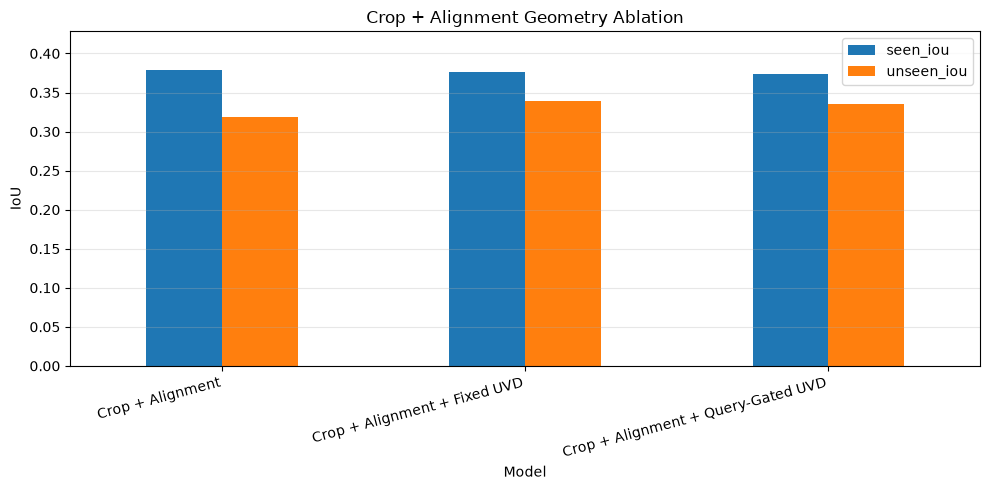

Saved: /home/hpc/v123be/v123be51/cv_notebooks/Computer_Vision_Object-Relative-Spatial-Encoding-for-Open-Vocabulary-Part-Segmentation/outputs/experiments/crop_alignment_query_gated_uvd/seen_unseen_model_comparison.png


In [50]:
plot_df = results_df.set_index("Model")[["seen_iou", "unseen_iou"]]

ax = plot_df.plot(
    kind="bar",
    figsize=(10, 5),
)

ax.set_ylabel("IoU")
ax.set_title("Crop + Alignment Geometry Ablation")
ax.set_ylim(0, max(0.4, plot_df.to_numpy().max() + 0.05))
ax.grid(axis="y", alpha=0.3)

plt.xticks(rotation=15, ha="right")
plt.tight_layout()

figure_path = OUTPUT_ROOT / "seen_unseen_model_comparison.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", figure_path)

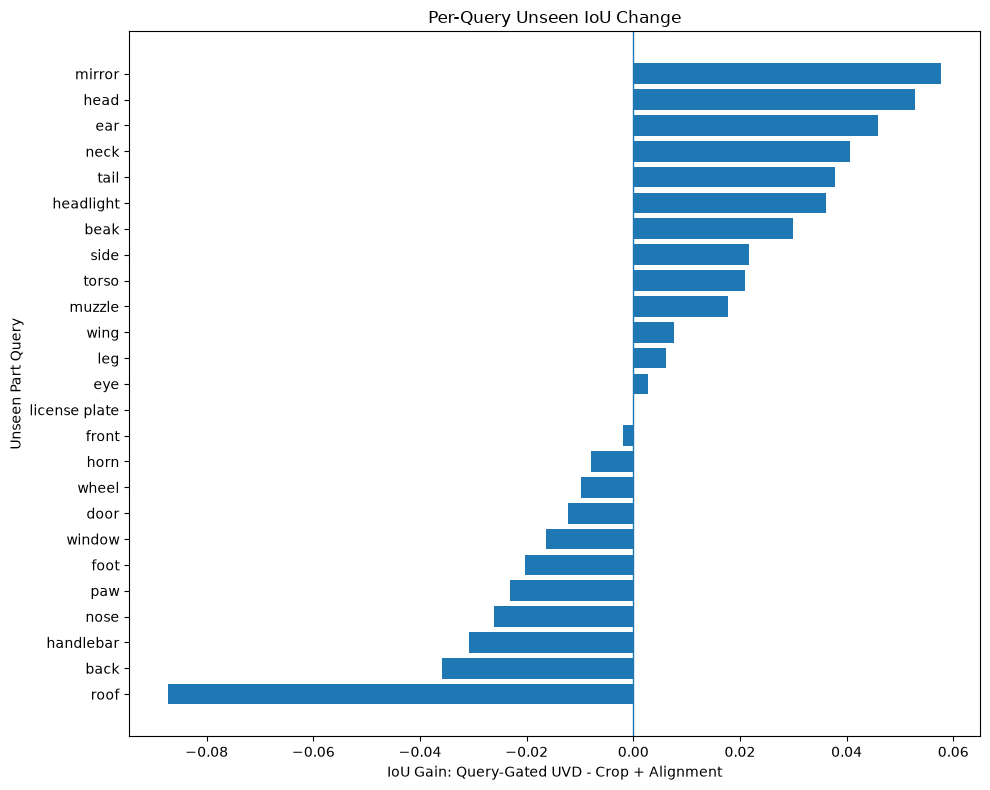

Saved: /home/hpc/v123be/v123be51/cv_notebooks/Computer_Vision_Object-Relative-Spatial-Encoding-for-Open-Vocabulary-Part-Segmentation/outputs/experiments/crop_alignment_query_gated_uvd/unseen_per_query_gated_gain.png


In [51]:
plot_df = per_query_df.sort_values(
    "gated_vs_baseline_gain",
    ascending=True,
)

plt.figure(figsize=(10, 8))
plt.barh(
    plot_df["query"],
    plot_df["gated_vs_baseline_gain"],
)
plt.axvline(0, linewidth=1)
plt.xlabel("IoU Gain: Query-Gated UVD - Crop + Alignment")
plt.ylabel("Unseen Part Query")
plt.title("Per-Query Unseen IoU Change")
plt.tight_layout()

figure_path = OUTPUT_ROOT / "unseen_per_query_gated_gain.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", figure_path)

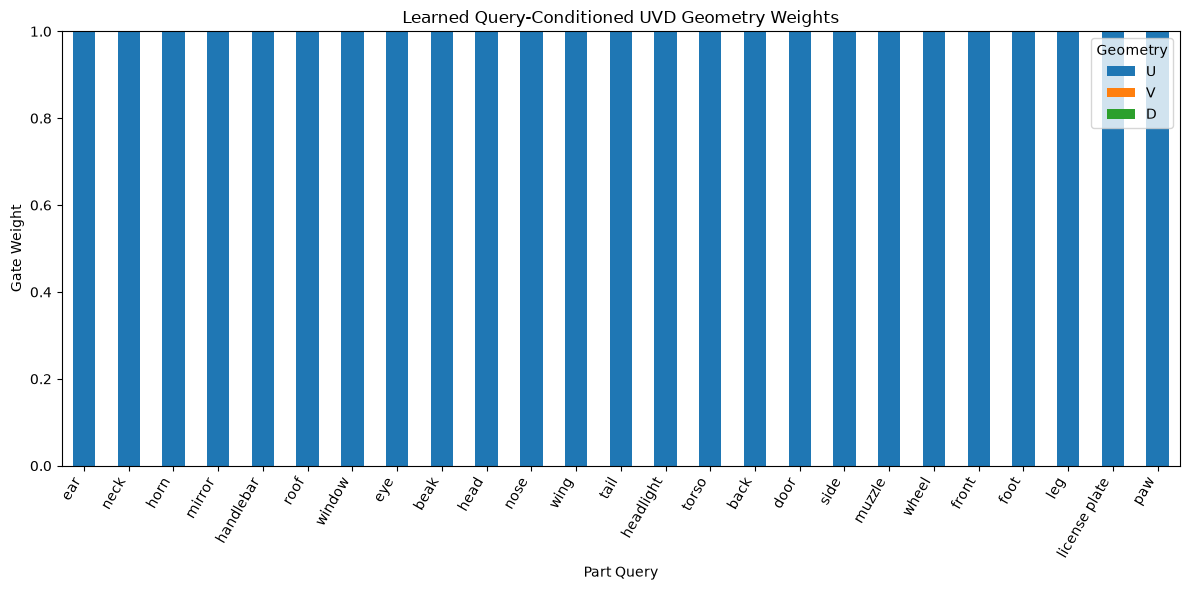

Saved: /home/hpc/v123be/v123be51/cv_notebooks/Computer_Vision_Object-Relative-Spatial-Encoding-for-Open-Vocabulary-Part-Segmentation/outputs/experiments/crop_alignment_query_gated_uvd/unseen_query_gate_weights.png


In [52]:
gate_plot_df = (
    unseen_gate_weights
    .sort_values("alpha_v")
    .set_index("query")
    [["alpha_u", "alpha_v", "alpha_d"]]
)

ax = gate_plot_df.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6),
)

ax.set_ylabel("Gate Weight")
ax.set_xlabel("Part Query")
ax.set_title("Learned Query-Conditioned UVD Geometry Weights")
ax.set_ylim(0, 1)
ax.legend(["U", "V", "D"], title="Geometry")

plt.xticks(rotation=60, ha="right")
plt.tight_layout()

figure_path = OUTPUT_ROOT / "unseen_query_gate_weights.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", figure_path)

## Result Summary

The cell below derives the main findings directly from the measured results instead of hard-coding a conclusion.

In [53]:
baseline_row = results_df[
    results_df["Model"] == "Crop + Alignment"
].iloc[0]

fixed_row = results_df[
    results_df["Model"] == "Crop + Alignment + Fixed UVD"
].iloc[0]

gated_row = results_df[
    results_df["Model"] == "Crop + Alignment + Query-Gated UVD"
].iloc[0]

summary = {
    "crop_alignment_unseen_iou": float(baseline_row["unseen_iou"]),
    "fixed_uvd_unseen_iou": float(fixed_row["unseen_iou"]),
    "query_gated_uvd_unseen_iou": float(gated_row["unseen_iou"]),
    "fixed_vs_baseline_unseen_gain": float(
        fixed_row["unseen_iou"] - baseline_row["unseen_iou"]
    ),
    "gated_vs_baseline_unseen_gain": float(
        gated_row["unseen_iou"] - baseline_row["unseen_iou"]
    ),
    "gated_vs_fixed_unseen_gain": float(
        gated_row["unseen_iou"] - fixed_row["unseen_iou"]
    ),
    "unseen_queries": int(len(per_query_df)),
    "gated_better_than_baseline_queries": int(
        (per_query_df["gated_vs_baseline_gain"] > 0).sum()
    ),
    "gated_better_than_fixed_queries": int(
        (per_query_df["gated_vs_fixed_gain"] > 0).sum()
    ),
    "mean_alpha_u": float(unseen_gate_weights["alpha_u"].mean()),
    "mean_alpha_v": float(unseen_gate_weights["alpha_v"].mean()),
    "mean_alpha_d": float(unseen_gate_weights["alpha_d"].mean()),
}

summary_path = OUTPUT_ROOT / "notebook10_summary.json"

with open(summary_path, "w") as f:
    json.dump(summary, f, indent=2)

print(json.dumps(summary, indent=2))
print()
print("Saved:", summary_path)

{
  "crop_alignment_unseen_iou": 0.31835454326559887,
  "fixed_uvd_unseen_iou": 0.33919148603724353,
  "query_gated_uvd_unseen_iou": 0.3349861232810483,
  "fixed_vs_baseline_unseen_gain": 0.020836942771644662,
  "gated_vs_baseline_unseen_gain": 0.016631580015449454,
  "gated_vs_fixed_unseen_gain": -0.004205362756195208,
  "unseen_queries": 25,
  "gated_better_than_baseline_queries": 13,
  "gated_better_than_fixed_queries": 10,
  "mean_alpha_u": 0.9999916291236878,
  "mean_alpha_v": 6.928528389578336e-07,
  "mean_alpha_d": 7.674949824240396e-06
}

Saved: /home/hpc/v123be/v123be51/cv_notebooks/Computer_Vision_Object-Relative-Spatial-Encoding-for-Open-Vocabulary-Part-Segmentation/outputs/experiments/crop_alignment_query_gated_uvd/notebook10_summary.json


## Interpretation Guide

Use the final results to answer three questions:

1. **Does fixed UVD improve Crop + Alignment?**  
   Compare `crop_alignment_fixed_uvd` with `crop_alignment`.

2. **Does query gating improve over fixed UVD?**  
   Compare `crop_alignment_query_gated_uvd` with `crop_alignment_fixed_uvd`.

3. **Does the gate still collapse?**  
   Inspect the mean and per-query values of `αU`, `αV`, and `αD`.

A strong positive result would require a clear unseen-category improvement without sacrificing seen performance. A small or inconsistent gain should be reported as an ablation finding rather than as evidence of a superior final architecture.

## Interpretation of Results

### 1. Does Fixed UVD Improve Crop + Alignment?

Yes, particularly on unseen parent-object categories.

- **Crop + Alignment:** unseen IoU = **0.3184**
- **Crop + Alignment + Fixed UVD:** unseen IoU = **0.3392**
- Absolute improvement = **+0.0208 IoU**

Seen IoU changes only slightly from **0.3784** to **0.3766**.

The relative seen-to-unseen generalization drop is also reduced from
**15.86%** to **9.93%**.

This indicates that object-relative UVD geometry provides useful spatial
information for generalizing part segmentation to unseen object categories.

### 2. Does Query Gating Improve Over Fixed UVD?

No.

- **Fixed UVD:** unseen IoU = **0.3392**
- **Query-Gated UVD:** unseen IoU = **0.3350**

Query gating therefore decreases unseen IoU by approximately **0.0042**
relative to fixed UVD.

However, Query-Gated UVD still substantially outperforms the model without
geometry:

- **Crop + Alignment:** 0.3184
- **Query-Gated UVD:** 0.3350
- Improvement = **+0.0166 IoU**

At the individual-query level, the gated model improves over the
Crop + Alignment baseline for **13 of 25** unseen part queries and improves
over Fixed UVD for **10 of 25** queries. This suggests that its effects are
query-dependent, but not consistently beneficial.

### 3. Does the Geometry Gate Collapse?

Yes.

The mean learned gate weights on unseen queries are approximately:

- **αU = 0.999992**
- **αV = 0.0000007**
- **αD = 0.0000077**

All **25 unseen part queries** select U as their dominant geometry channel.

Therefore, the softmax gate has effectively collapsed to a nearly
query-independent horizontal-coordinate selector rather than learning a
meaningful combination of U, V, and D.

## Conclusion

The strongest configuration in this experiment is:

**Crop + Alignment + Fixed UVD**

with:

- **Seen IoU: 0.3766**
- **Unseen IoU: 0.3392**
- **Unseen Dice: 0.4503**

The experiment provides evidence that object-relative geometry improves
generalization to unseen parent-object categories when combined with
object-centric cropping and part-query alignment.

However, the current softmax query-gating mechanism does not improve over
fixed UVD geometry. Its near-complete collapse onto the U channel suggests
that competitive softmax gating is too restrictive in this architecture.

Therefore, Query-Gated UVD should be interpreted as an **ablation finding**
rather than as the superior final architecture.

## Final Experiment Summary

This notebook evaluated whether object-relative UVD geometry improves the
strongest object-centric part segmentation architecture.

The main findings are:

1. **Object-centric cropping and part-query alignment provide a strong base
   architecture**, achieving an unseen IoU of **0.3184**.

2. **Fixed UVD geometry improves unseen-category generalization**, increasing
   unseen IoU to **0.3392** while reducing the relative seen-to-unseen
   generalization drop from **15.86% to 9.93%**.

3. **Query-Gated UVD also improves over the no-geometry baseline**, reaching
   an unseen IoU of **0.3350**, but it does not outperform Fixed UVD.

4. The learned softmax geometry gate **collapses almost entirely to the U
   coordinate**, with all 25 unseen queries selecting U as the dominant
   geometry channel.

Overall, the experiments support the use of **object-relative spatial
geometry for open-vocabulary part segmentation**, but do not support the
current softmax query-gating mechanism as an improvement over fixed UVD.

The best configuration from this experiment is therefore:

> **Object-Centric Crop + Part-Query Alignment + Fixed UVD**

with **0.3392 unseen IoU** and **0.4503 unseen Dice**.

SyntaxError: invalid syntax (682396458.py, line 1)